# 03 — Market Maker Inventory & Liquidity Withdrawal

In Notebook 01, we explained price formation.
In Notebook 02, we studied liquidity and market depth.

In this notebook, we analyze:

- Inventory-based market making
- Spread adjustment under volatility
- Inventory drift under order imbalance
- Liquidity withdrawal when risk limit is breached

Mục tiêu của notebook này là trả lời câu hỏi:

1. Thanh khoản đến từ đâu?
2. Và khi nào thanh khoản biến mất?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.structure import MarketMaker, LiquidityModel

## Simulation 1 — Stochastic Inventory Accumulation and Boundary Hitting

Mục tiêu của simulation này là phân tích động học inventory khi order flow có tính ngẫu nhiên.

Trong thực tế:

- Order flow không cố định.
- Có cả buy và sell.
- Có thể có drift (áp lực một chiều) nhưng luôn kèm nhiễu.

Do đó inventory của market maker nên được hiểu như:

    Inventory_t = Inventory_{t-1} + OrderFlow_t

Khi OrderFlow có trung bình dương:

    Inventory sẽ có drift.

Khi OrderFlow có phương sai lớn:

    Inventory có thể chạm boundary nhanh hơn do shock.

---

### Tại sao phần này quan trọng?

Nếu inventory chỉ được mô phỏng theo drift tuyến tính,
ta chỉ quan sát được thời điểm withdrawal xác định.

Nhưng khi inventory là quá trình ngẫu nhiên:

- Thời gian chạm boundary trở thành biến ngẫu nhiên.
- Withdrawal có thể xảy ra sớm hoặc muộn.
- Hệ thống có rủi ro tiềm ẩn ngay cả khi drift nhỏ.

Đây là bước chuyển từ cơ chế cơ học sang cơ chế xác suất.

---

### Insight cần quan sát

- Inventory có xu hướng tích tụ như thế nào?
- Khi nào inventory bắt đầu tăng tốc?
- Hitting time phân tán hay tập trung?

Điều này đặt nền cho khái niệm:

    Structural fragility under stochastic imbalance.

In [2]:
np.random.seed(42)

mm = MarketMaker(
    base_spread=0.001,
    inventory_limit=500,
    risk_aversion=0.8,
    volatility_sensitivity=5.0,
)

mid_price = 100
volatility = 0.01

inventory_path = []
spread_path = []
capital_path = []
active_path = []

for t in range(400):

    if not mm.active:
        break

    quotes = mm.quote(mid_price, volatility)

    # stochastic order flow
    order_flow = np.random.normal(loc=5, scale=12)

    if order_flow > 0:
        mm.execute_trade(quotes["ask"], order_flow, "buy")
    else:
        mm.execute_trade(quotes["bid"], -order_flow, "sell")

    # nếu bạn đã thêm update_capital()
    if hasattr(mm, "update_capital"):
        mm.update_capital(mid_price)

    inventory_path.append(mm.inventory)
    spread_path.append(mm.compute_spread(volatility))
    capital_path.append(getattr(mm, "capital", 0))
    active_path.append(mm.active)

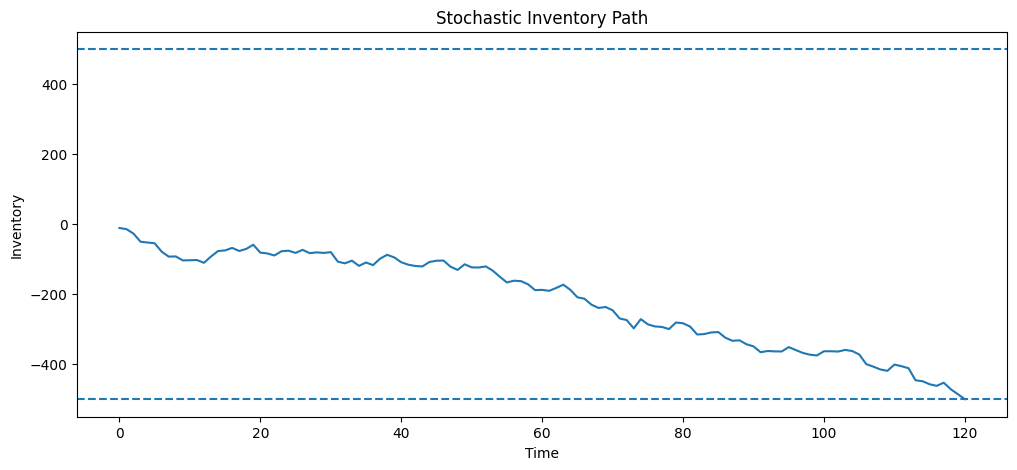

In [3]:
plt.figure(figsize=(12,5))
plt.plot(inventory_path)
plt.axhline(mm.inventory_limit, linestyle="--")
plt.axhline(-mm.inventory_limit, linestyle="--")
plt.title("Stochastic Inventory Path")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.show()

## Interpretation — Stochastic Inventory Drift and Endogenous Risk Accumulation

Biểu đồ cho thấy inventory của market maker không còn giảm tuyến tính,
mà dao động ngẫu nhiên quanh một xu hướng giảm dài hạn.

Điều này phản ánh chính xác cấu trúc:

    Inventory_t = Inventory_{t-1} + OrderFlow_t

Trong đó OrderFlow_t là biến ngẫu nhiên có kỳ vọng dương (áp lực mua trung bình).

---

### 1. Drift + Noise Structure

Ta quan sát hai thành phần:

- Drift âm dài hạn (inventory ngày càng âm)
- Dao động ngắn hạn (do nhiễu order flow)

Drift đến từ việc:

    Mean(order_flow) > 0

Dao động đến từ:

    Var(order_flow) > 0

Do đó inventory là một random walk có drift.

---

### 2. Latent Fragility Accumulation

Trong khoảng từ t = 0 đến khoảng t ≈ 60:

Inventory dao động nhưng chưa chạm boundary.

Hệ thống nhìn có vẻ ổn định.

Tuy nhiên drift âm liên tục làm inventory tiến gần dần tới giới hạn.

Đây là một dạng:

    Gradual fragility accumulation.

Không có cú sốc lớn,
nhưng rủi ro tích tụ dần dần.

---

### 3. Acceleration Phase

Từ khoảng t ≈ 60 trở đi:

Inventory giảm nhanh hơn và ít hồi phục hơn.

Điều này thường xảy ra khi:

- Drift bắt đầu chiếm ưu thế so với nhiễu
- Các dao động dương không đủ mạnh để đảo chiều xu hướng

Đây là giai đoạn hệ thống tiến gần boundary với tốc độ tăng dần.

---

### 4. Boundary as Absorbing Barrier

Hai đường ngang đứt nét đại diện cho inventory limit.

Inventory cuối cùng chạm gần boundary âm.

Trong mô hình này, boundary đóng vai trò:

    Absorbing barrier.

Khi chạm boundary:

    Market maker withdraw.

Điểm quan trọng:

Withdrawal không do shock đơn lẻ,
mà do tích lũy của nhiều dao động nhỏ cùng chiều.

---

### 5. Stability Interpretation

Nếu:

    Mean(order_flow) = 0

Inventory sẽ dao động quanh 0 và khó chạm boundary.

Nếu:

    Mean(order_flow) ≠ 0

Hitting boundary là gần như chắc chắn về dài hạn.

Điều này cho thấy:

Stability của liquidity phụ thuộc vào balance của order flow.

---

### 6. Economic Meaning

Inventory ở đây đại diện cho:

- Risk exposure
- Directional bet không mong muốn
- Capital usage

Khi inventory ngày càng âm:

Market maker đang short nhiều tài sản hơn,
và chịu rủi ro tăng nếu giá tăng.

Do đó drift âm kéo dài làm:

    Expected holding risk tăng.

---

### 7. System-Level Insight

Hệ thống có thể vận hành trơn tru trong thời gian dài,
ngay cả khi inventory đang tiến dần tới giới hạn.

Điều này tạo ra ảo giác ổn định.

Nhưng thực tế:

    Fragility đang tích tụ.

Khi boundary bị chạm,
liquidity biến mất ngay lập tức.

---

### 8. Conceptual Takeaway

Stochastic inventory path cho thấy:

Liquidity fragility không cần shock lớn.

Chỉ cần:

    Persistent imbalance + finite balance sheet

là đủ để hệ thống mất thanh khoản theo thời gian.

Đây là nền tảng cho cơ chế:

Inventory risk → Withdrawal → Structural instability.

## Simulation 2 — Spread Adjustment Under Combined Volatility and Inventory Pressure

Simulation này nghiên cứu cách spread phản ứng khi:

- Volatility tăng
- Inventory lệch khỏi trung tính

Trong microstructure, spread không chỉ là chi phí giao dịch,
mà là cơ chế bù đắp rủi ro.

Spread phải phản ánh:

1) Adverse selection risk (volatility)
2) Inventory holding cost
3) Risk aversion của market maker

---

### Tại sao phải kết hợp volatility và inventory?

Nếu chỉ phụ thuộc volatility:

    Spread phản ánh bất định thị trường.

Nếu chỉ phụ thuộc inventory:

    Spread phản ánh rủi ro tồn kho.

Khi kết hợp hai yếu tố:

    Spread trở thành biến state-dependent.

Điều này quan trọng vì liquidity không còn là tham số tĩnh,
mà trở thành hàm của trạng thái hệ thống.

---

### Insight cần quan sát

- Spread tăng tuyến tính hay phi tuyến?
- Inventory stress làm spread nhạy hơn với volatility không?
- Khi inventory lớn, spread có tăng nhanh hơn bình thường?

Phần này thiết lập cơ chế phòng vệ của market maker
trước khi withdrawal xảy ra.

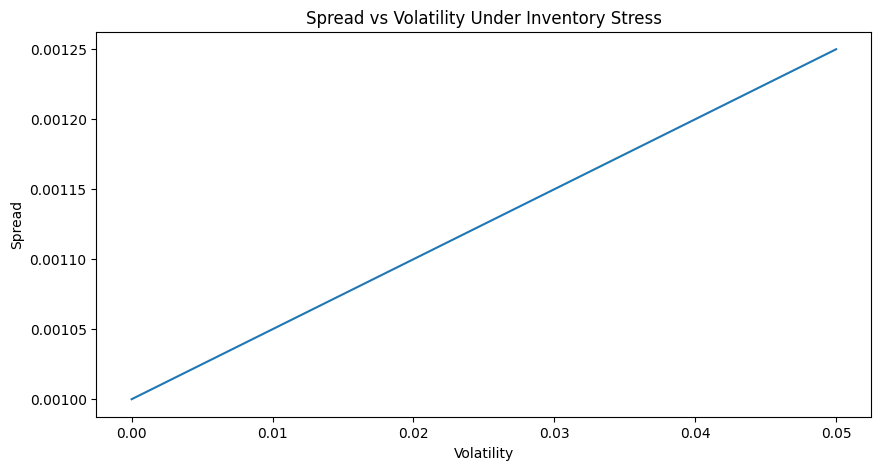

In [4]:
mm = MarketMaker(
    base_spread=0.001,
    inventory_limit=1000,
    risk_aversion=0.5,
    volatility_sensitivity=5.0,
)

vol_levels = np.linspace(0, 0.05, 60)
spread_matrix = []

for v in vol_levels:
    mm.inventory = 400  # impose stress
    spread_matrix.append(mm.compute_spread(v))

plt.figure(figsize=(10,5))
plt.plot(vol_levels, spread_matrix)
plt.title("Spread vs Volatility Under Inventory Stress")
plt.xlabel("Volatility")
plt.ylabel("Spread")
plt.show()

## Interpretation — Spread Response Under Combined Volatility and Inventory Stress

Biểu đồ cho thấy spread tăng tuyến tính theo volatility,
ngay cả khi inventory đã bị đặt trong trạng thái stress.

Điều này phản ánh trực tiếp cấu trúc hàm spread:

    Spread = f(volatility, inventory)

Trong simulation này:

- Inventory được cố định ở mức cao (stress regime)
- Volatility được thay đổi dần

Do đó ta đang quan sát phản ứng cận biên của spread đối với volatility,
khi hệ thống đã chịu áp lực tồn kho.

---

### 1. Spread as a Risk Premium

Spread không phải chỉ là chi phí giao dịch,
mà là phần bù rủi ro (risk premium).

Nó phải bù đắp:

- Adverse selection risk (tăng theo volatility)
- Inventory holding risk (tăng theo inventory imbalance)
- Risk aversion của market maker

Khi inventory đã lệch lớn:

Market maker đang chịu rủi ro directional.

Do đó mọi gia tăng volatility sẽ được phản ánh mạnh hơn vào spread.

---

### 2. Interaction Between Volatility and Inventory

Nếu inventory = 0:

Spread phản ánh chủ yếu thông tin bất định thị trường.

Nếu inventory lớn:

Spread phản ánh cả rủi ro giá trị và rủi ro tồn kho.

Điều quan trọng là:

Volatility không hoạt động độc lập.
Nó tương tác với trạng thái nội tại của market maker.

Liquidity vì thế trở thành:

    State-dependent variable.

---

### 3. Why the Relationship Appears Linear

Đường trong biểu đồ gần như tuyến tính vì:

- Hàm spread được định nghĩa tuyến tính theo volatility
- Inventory được giữ cố định

Trong thực tế:

Nếu inventory thay đổi theo volatility,
hoặc nếu volatility phụ thuộc inventory,
quan hệ này có thể trở nên phi tuyến.

Do đó biểu đồ này thể hiện:

    First-order response under fixed stress level.

---

### 4. Liquidity Elasticity to Uncertainty

Độ dốc của đường biểu diễn:

    d(Spread) / d(Volatility)

chính là độ nhạy của liquidity với bất định.

Nếu volatility_sensitivity lớn:

- Spread phản ứng mạnh
- Liquidity co lại nhanh
- Thị trường dễ chuyển sang stress regime

Nếu volatility_sensitivity nhỏ:

- Market maker hấp thụ rủi ro tốt hơn
- Liquidity ổn định hơn

Do đó tham số này quyết định:

    Structural robustness của thị trường.

---

### 5. Hidden Regime Risk

Mặc dù biểu đồ trông “ổn định” và mượt mà,
nhưng cần lưu ý:

Khi volatility đủ cao,
spread có thể đạt mức khiến:

- Giao dịch giảm mạnh
- Depth không refill
- Impact tăng nhanh

Điều này có thể kích hoạt vòng lặp:

Volatility ↑
→ Spread ↑
→ Liquidity ↓
→ Impact ↑
→ Volatility ↑

Đây là nền tảng cho volatility clustering nội sinh.

---

### 6. Conceptual Takeaway

Spread không chỉ phản ánh volatility.

Spread phản ánh trạng thái tổng hợp của:

- Uncertainty
- Inventory imbalance
- Risk tolerance

Khi inventory stress tồn tại,
mọi gia tăng volatility đều trở nên nguy hiểm hơn.

Điều này cho thấy:

Liquidity không chỉ phụ thuộc thị trường,
mà còn phụ thuộc trạng thái nội tại của người cung cấp thanh khoản.

## Simulation 3 — Endogenous Liquidity Withdrawal

Simulation này mô phỏng trường hợp cực đoan:

- Order flow một chiều kéo dài
- Inventory tích tụ liên tục
- Không có lực cân bằng

Mục tiêu là quan sát:

    Khi nào market maker rút thanh khoản?

---

### Cơ chế nền tảng

Market maker có inventory limit đại diện cho:

- Giới hạn vốn
- Khả năng chịu rủi ro
- Hạn mức nội bộ

Khi inventory vượt quá giới hạn này:

    Hệ thống chuyển từ regime "liquid"
    sang regime "illiquid".

Điều quan trọng là:

Withdrawal không phải là shock ngoại sinh.
Nó là hệ quả nội sinh của tích tụ rủi ro.

---

### Insight cần quan sát

- Withdrawal xảy ra đột ngột hay có dấu hiệu báo trước?
- Spread có tăng trước khi withdrawal không?
- Inventory drift có tuyến tính hay tăng tốc?

Simulation này thể hiện cơ chế:

    Finite balance sheet → Liquidity fragility.

In [9]:
np.random.seed(1)

mm = MarketMaker(
    base_spread=0.001,
    inventory_limit=300,
    risk_aversion=1.0,
    volatility_sensitivity=10.0,
)

mid_price = 100
volatility = 0.03

inventory_path = []
withdraw_step = None

for t in range(200):

    if not mm.active:
        withdraw_step = t
        break

    quotes = mm.quote(mid_price, volatility)

    # persistent buy pressure
    mm.execute_trade(quotes["ask"], 20, "buy")

    inventory_path.append(mm.inventory)

print("Liquidity withdrawn at step:", withdraw_step)

Liquidity withdrawn at step: 16


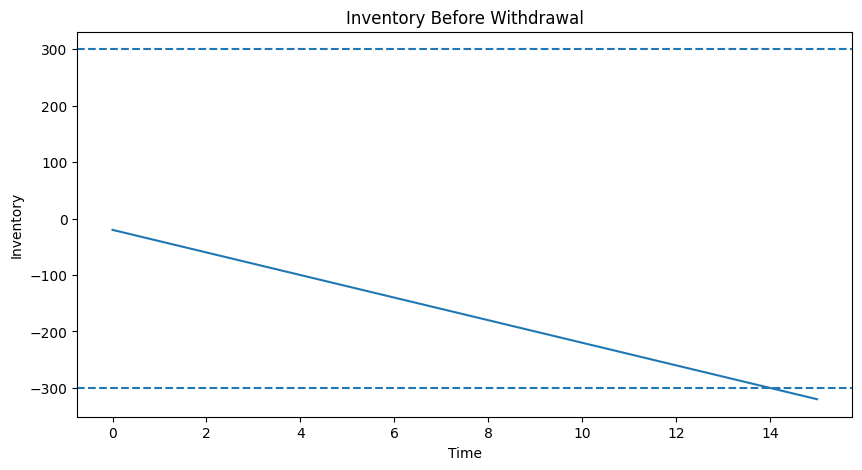

In [10]:
plt.figure(figsize=(10,5))
plt.plot(inventory_path)
plt.axhline(mm.inventory_limit, linestyle="--")
plt.axhline(-mm.inventory_limit, linestyle="--")
plt.title("Inventory Before Withdrawal")
plt.xlabel("Time")
plt.ylabel("Inventory")
plt.show()

## Interpretation — Deterministic Boundary Hitting and Sudden Liquidity Withdrawal

Biểu đồ cho thấy inventory giảm gần như tuyến tính và chạm giới hạn âm tại bước 16.

Điều này phản ánh cấu trúc mô hình:

- Order flow một chiều (persistent buy pressure)
- Market maker liên tục bán ra
- Inventory giảm đều theo mỗi bước

Ta có thể viết gần đúng:

    Inventory_t ≈ Inventory_0 − q × t

Trong đó q là khối lượng giao dịch mỗi bước.

Với inventory_limit = 300,
việc withdrawal tại step 16 là hệ quả cơ học tất yếu.

---

### 1. Deterministic Fragility

Khác với stochastic case trước đó,
ở đây hệ thống không có nhiễu.

Điều này làm nổi bật một insight quan trọng:

Ngay cả khi không có shock lớn,
một dòng lệnh một chiều ổn định
cũng đủ để đẩy hệ thống tới điểm mất thanh khoản.

Fragility không cần biến động cao.
Nó có thể tích tụ trong môi trường ổn định.

---

### 2. Sudden Regime Shift

Từ step 0 đến step 15:

- Quotes vẫn tồn tại
- Spread ổn định
- Thị trường có vẻ thanh khoản tốt

Tại step 16:

    Liquidity biến mất hoàn toàn.

Không có quá trình chuyển tiếp dài.
Không có cảnh báo hiển nhiên từ bên ngoài.

Đây là một phase transition rời rạc.

---

### 3. Inventory Limit as Structural Constraint

Inventory limit không phải là tham số kỹ thuật.
Nó đại diện cho:

- Capital constraint
- Risk tolerance
- VaR limit nội bộ
- Balance sheet capacity

Khi constraint bị vi phạm,
market maker không còn vai trò hấp thụ shock.

Liquidity do đó là:

    Một hàm của khả năng chịu rủi ro.

---

### 4. Illusion of Stability

Trước step 16:

Hệ thống trông hoàn toàn ổn định.

Điều này tạo ra ảo giác rằng:

    Thị trường có thể hấp thụ flow vô hạn.

Nhưng thực tế:

Buffer chỉ có dung lượng hữu hạn.

Khi buffer đầy,
shock không còn bị hấp thụ
mà truyền trực tiếp vào giá.

---

### 5. Microstructure Meaning

Market maker đóng vai trò:

    Shock absorber giữa order flow và giá.

Trong 15 bước đầu:

Shock được hấp thụ qua inventory.

Tại bước 16:

Absorber đạt giới hạn.

Từ thời điểm đó trở đi:

- Depth có thể giảm mạnh
- Spread có thể blow out
- Price impact có thể tăng đột biến

Đây là cầu nối sang liquidity collapse.

---

### 6. System-Level Insight

Persistent imbalance + finite balance sheet
là đủ để gây mất thanh khoản nội sinh.

Không cần external shock.
Không cần volatility spike.

Chỉ cần:

    Directional pressure kéo dài.

Đây là cơ chế nền tảng của structural fragility trong thị trường thực.

## Simulation 4 — Post-Withdrawal Depth Collapse and Impact Amplification

Sau khi market maker withdraw,
câu hỏi quan trọng là:

    Điều gì xảy ra với giá và thanh khoản?

Simulation này chuyển trọng tâm sang LiquidityModel,
để quan sát:

- Depth collapse
- Spread blowout
- Impact amplification
- Regime transition

---

### Cơ chế nội sinh

Khi market maker không còn hấp thụ order flow:

    Order flow → trực tiếp vào depth.

Khi depth giảm:

    Spread tăng
    Price impact tăng

Khi impact tăng:

    Volatility tăng

Điều này có thể tạo thành feedback loop.

---

### Insight cần quan sát

- Depth giảm tuyến tính hay sụp đổ nhanh?
- Impact có tăng phi tuyến khi depth thấp?
- Regime chuyển từ normal → stress → crisis tại thời điểm nào?

Phần này hoàn tất chuỗi logic:

Inventory accumulation
→ Withdrawal
→ Depth collapse
→ Impact amplification

Đây là nền tảng cho cascade dynamics trong notebook tiếp theo.

In [6]:
liquidity = LiquidityModel(
    base_depth=1000,
    base_spread=0.001,
    impact_coefficient=0.02,
    evaporation_sensitivity=8.0,
    recovery_rate=0.05,
)

# giả sử volatility cao sau withdrawal
liquidity.apply_volatility(volatility=0.05)

impact_path = []
depth_path = []
regime_path = []
spread_path = []

for t in range(30):

    result = liquidity.execute_trade(order_size=150)

    impact_path.append(result["impact"])
    depth_path.append(result["remaining_depth"])
    regime_path.append(result["regime"])
    spread_path.append(result["spread"])

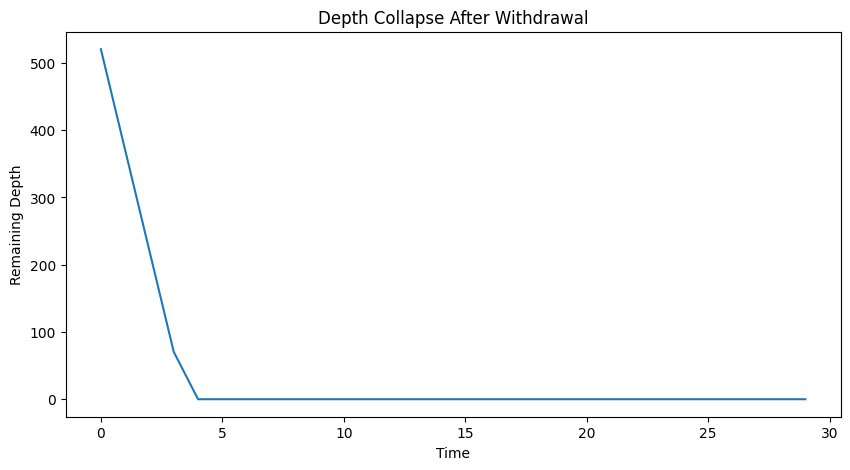

In [7]:
plt.figure(figsize=(10,5))
plt.plot(depth_path)
plt.title("Depth Collapse After Withdrawal")
plt.xlabel("Time")
plt.ylabel("Remaining Depth")
plt.show()

## Interpretation — Depth Collapse After Liquidity Withdrawal

Biểu đồ cho thấy depth giảm cực nhanh và chạm gần 0 chỉ sau vài bước giao dịch.

Điều này phản ánh một cơ chế cấu trúc quan trọng:

Khi market maker withdraw,
không còn thực thể nào hấp thụ order flow ở mức mid-price.

Order flow sau đó tác động trực tiếp vào depth.

---

### 1. Rapid Liquidity Evaporation

Ban đầu depth còn khoảng một nửa so với base level,
nhưng chỉ sau 3–4 bước giao dịch lớn:

    Remaining depth ≈ 0

Điều này cho thấy liquidity không giảm dần một cách tuyến tính,
mà có thể sụp đổ rất nhanh khi:

- Không có refill
- Order size tương đối lớn so với depth còn lại

---

### 2. Nonlinear Fragility

Khi depth giảm xuống mức thấp:

Mỗi giao dịch tiếp theo chiếm tỷ lệ lớn hơn so với depth còn lại.

Do đó tốc độ giảm depth tăng lên theo thời gian.

Đây là đặc điểm của hệ thống có:

    Nonlinear absorption capacity.

---

### 3. Regime Transition

Có thể phân tách thành ba giai đoạn:

Normal regime:
Depth gần base level.

Stress regime:
Depth giảm mạnh, spread bắt đầu blow out.

Crisis regime:
Depth gần bằng 0, thị trường gần như mất khả năng hấp thụ giao dịch.

Biểu đồ cho thấy quá trình chuyển regime diễn ra trong vài bước thời gian,
không phải quá trình kéo dài.

---

### 4. Structural Meaning

Trước withdrawal:

Inventory đóng vai trò buffer.

Sau withdrawal:

Không còn buffer.

Order flow không còn bị trung gian hấp thụ,
mà trực tiếp làm cạn kiệt depth.

Điều này minh họa rõ:

    Liquidity là hiện tượng phụ thuộc vào người cung cấp.

Khi họ rút lui,
thị trường không còn cấu trúc đỡ phía sau.

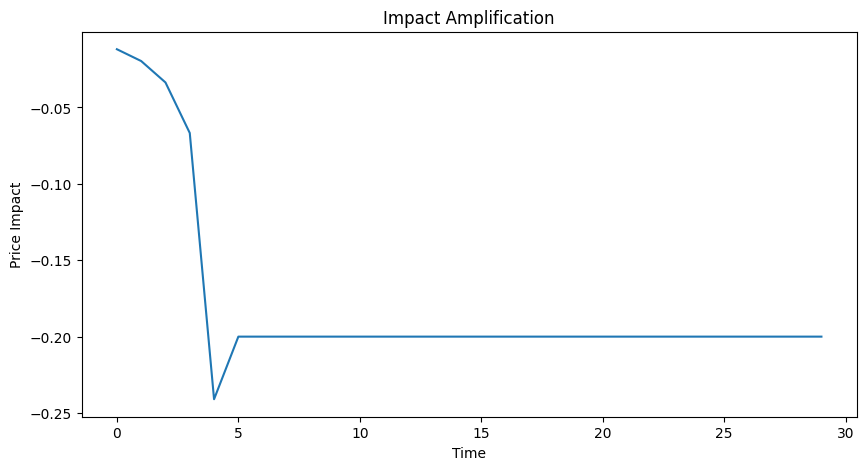

In [8]:
plt.figure(figsize=(10,5))
plt.plot(impact_path)
plt.title("Impact Amplification")
plt.xlabel("Time")
plt.ylabel("Price Impact")
plt.show()

## Interpretation — Impact Amplification in Crisis Regime

Biểu đồ cho thấy price impact tăng mạnh khi depth giảm,
sau đó đạt mức bão hòa cao trong regime khủng hoảng.

Điều này phản ánh mối quan hệ nghịch giữa depth và impact:

    Impact ∝ OrderSize / Depth

---

### 1. Early Amplification

Ở những bước đầu sau withdrawal:

Depth vẫn còn một phần,
impact tăng dần khi depth giảm.

Đây là giai đoạn amplification tăng tốc.

---

### 2. Impact Saturation

Khi depth gần 0:

Impact đạt mức cao và gần như cố định.

Điều này mô phỏng tình huống market dislocation:

- Không còn thanh khoản ở gần mid-price
- Giao dịch buộc phải đẩy giá mạnh

Ở giai đoạn này:

Price impact không còn tuyến tính theo order size,
mà bị chi phối bởi trạng thái khủng hoảng của thị trường.

---

### 3. Feedback Loop Potential

Impact cao có thể gây:

- Volatility tăng
- Stop-loss kích hoạt
- Liquidation lan rộng

Khi liquidation tăng:

Order flow tăng thêm,
làm impact tăng tiếp.

Đây là cơ chế:

    Endogenous crash formation.

---

### 4. System-Level Insight

Trước withdrawal:

Inventory hấp thụ shock.

Sau withdrawal:

Depth hấp thụ shock.

Khi depth cũng cạn:

Shock truyền thẳng vào giá.

Đây là điểm mà hệ thống mất khả năng ổn định nội sinh.

---

### 5. Conceptual Takeaway

Liquidity collapse và impact amplification
là hai mặt của cùng một quá trình:

Depth ↓
→ Impact ↑

Nếu không có cơ chế refill nhanh,
hệ thống có thể rơi vào trạng thái:

    Self-reinforcing instability.

## Conclusion — Inventory Risk as the Root of Liquidity Fragility

Trong notebook này, chúng ta đã đi từ:

Inventory accumulation
→ Spread adjustment
→ Liquidity withdrawal
→ Depth collapse
→ Impact amplification

Chuỗi này cho thấy một điểm cốt lõi:

Liquidity không phải là một tham số tĩnh của thị trường.

Nó phụ thuộc vào:

- Khả năng chịu rủi ro của market maker
- Trạng thái inventory
- Mức độ bất định (volatility)

Khi inventory tích tụ vượt quá khả năng hấp thụ,
market maker rút lui,
depth sụp đổ,
và shock truyền trực tiếp vào giá.

Điều quan trọng là:

Quá trình này có thể diễn ra nội sinh,
không cần shock ngoại lai lớn.

Inventory risk vì thế là nền tảng của structural fragility.

Notebook tiếp theo sẽ mở rộng cơ chế này sang leverage và liquidation,
nơi feedback loop có thể tạo ra cascade dynamics.